# FYM on the DiTFlow DAVIS50 benchmark (Colab)

Protocol: `steps.md`. Rows per clip: `backbone` (clean Wan2.1-T2V-1.3B) and `fym` (per-clip spatial + temporal LoRA tuning).
The claim is the paired per-clip `fym - backbone` with a bootstrap CI.

Every session: cells 1-5. Then the pilot (6-8) or the full run (9-11).
Results live on Drive, so a recycled runtime loses nothing: re-run cells 1-5 and re-issue the run; finished cells are skipped.

Runtime: **A100 40GB, High-RAM**.

In [1]:
# 1. Paths and pins
DRIVE    = "/content/drive/MyDrive/ditflow"
RUNS     = f"{DRIVE}/runs"                    # run tree; collect.py reads it
BENCH    = "/content/bench"                   # tars unpacked here each session
MODELS   = "/content/models/Wan2.1-T2V-1.3B"  # local: tuning reads the weights several times per clip
REPO     = "/content/FollowYourMotion"
GIT_URL  = "https://github.com/jnheinrich451-eng/FollowYourMotion.git"
BRANCH   = "davis-bench"
WAN_REPO = "Wan-AI/Wan2.1-T2V-1.3B"
# DiTFlow scored with CoTracker unpinned (hub 'main'). main has not moved since this commit
# (2025-01-21) and the cotracker3 weights not since 2024-10, so this is the tracker it used.
COTRACKER_REF = "82e02e8029753ad4ef13cf06be7f4fc5facdda4d"

In [2]:
# 2. Drive, GPU, RAM -- stops here on the wrong runtime rather than partway through a run
from google.colab import drive
drive.mount("/content/drive")
import subprocess, os
gpu = subprocess.check_output(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], text=True).strip()
ram_gb = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 2**30
print(f"GPU: {gpu} | RAM: {ram_gb:.0f} GB")
assert "A100" in gpu, "not an A100: create a new Colab server with the A100 accelerator and reconnect"
assert ram_gb > 40, "standard RAM: pick High-RAM (the text encoder alone is ~11 GB in CPU RAM)"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA A100-SXM4-40GB, 40960 MiB | RAM: 83 GB


In [3]:
# 3. Code and dependencies (Colab's own torch is used; transformers pinned to the repo's
#    requirements.txt, since the 5.x Colab ships breaks diffsynth's imports)
import os
if not os.path.exists(REPO):
    !git clone -q -b {BRANCH} {GIT_URL} {REPO}
!git -C {REPO} pull -q; git -C {REPO} log --oneline -1
!pip install -q transformers==4.46.2 lightning==2.6.1 peft==0.18.1 modelscope ftfy sentencepiece einops imageio imageio-ffmpeg lpips git+https://github.com/openai/CLIP.git
!cd {REPO} && python -c "import transformers, diffsynth, diffsynth_collect_attn, peft, lightning; print('imports ok, transformers', transformers.__version__)"

83d45ba (HEAD -> davis-bench, origin/davis-bench) Check the pipeline's imports at setup, before any run
  Preparing metadata (setup.py) ... done
2026-09-27 16:06:21.471723: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-27 16:06:21.541757: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
imports ok, transformers 4.46.2


In [4]:
# 4. Benchmark data: unpack every tar on Drive, find the packed root and the masks, remap the manifest
import glob, pathlib, subprocess
os.makedirs(BENCH, exist_ok=True)
for t in sorted(glob.glob(f"{DRIVE}/*.tar")):
    marker = pathlib.Path(BENCH) / (".unpacked_" + pathlib.Path(t).name)
    if not marker.exists():
        print("unpacking", t)
        subprocess.run(["tar", "-xf", t, "-C", BENCH], check=True)
        marker.touch()

metas = [p for p in pathlib.Path(BENCH).rglob("camel/meta.json") if p.parents[1].name == "davis"]
masks = list(pathlib.Path(BENCH).rglob("camel/00000.png"))
assert metas, "no davis/camel/meta.json under BENCH: is the packed tar on Drive?"
assert masks, "no camel/00000.png under BENCH: is the annotations tar on Drive?"
PACKED, ANNOT = str(metas[0].parents[2]), str(masks[0].parents[1])
MANIFEST = "/content/davis50_local.csv"
print("packed:", PACKED, "| annotations:", ANNOT)
subprocess.run(["python", "benchmark/remap.py", "--manifest", "benchmark/davis50.csv", "--out", MANIFEST,
                "--from", "E:\\bench\\packed", "--to", PACKED, "--verify"], cwd=REPO, check=True)

packed: /content/bench/packed | annotations: /content/bench/davis_annotations


CompletedProcess(args=['python', 'benchmark/remap.py', '--manifest', 'benchmark/davis50.csv', '--out', '/content/davis50_local.csv', '--from', 'E:\\bench\\packed', '--to', '/content/bench/packed', '--verify'], returncode=0)

In [5]:
# 5. Wan2.1-T2V-1.3B, pinned: the first session records the revision on Drive, later sessions reuse it
from huggingface_hub import HfApi, snapshot_download
pin = pathlib.Path(DRIVE) / "fym_wan_REVISION"
rev = pin.read_text().strip() if pin.exists() else HfApi().model_info(WAN_REPO).sha
pin.write_text(rev)
if not os.path.exists(f"{MODELS}/diffusion_pytorch_model.safetensors"):
    snapshot_download(WAN_REPO, revision=rev, local_dir=MODELS)
pathlib.Path(MODELS, "REVISION").write_text(f"{WAN_REPO}@{rev}")
print(f"{WAN_REPO}@{rev}")

Wan-AI/Wan2.1-T2V-1.3B@37ec512624d61f7aa208f7ea8140a131f93afc9a


## Pilot: `camel`, both rows

Also runs `fym_biasfix` (the pretrained q/k/v biases kept through the head split). It checks whether the release's random biases matter; it is not a headline row. Leave it out of the full run unless the pilot says it matters.

Check before the full run:
- `temporal heads per layer` varies across layers (not all 0 or all 12);
- the contact sheet: backbone and fym show the new subject, and fym moves like the reference;
- the scores table has a value in every column.

In [6]:
# 6. Pilot run
!cd {REPO} && python fym_bench/run_davis.py --manifest {MANIFEST} --runs {RUNS} --models {MODELS} --clips camel --configs backbone,fym,fym_biasfix

1 clips x ['backbone', 'fym', 'fym_biasfix']; checkpoint Wan-AI/Wan2.1-T2V-1.3B@37ec512624d61f7aa208f7ea8140a131f93afc9a; repo 83d45ba88d4b56d379b2f9739afacdd676b06325; gpu NVIDIA A100-SXM4-40GB
[1/1] camel
      generate: 69s, peak 11668 MB
    backbone: ok (tune 0s, generate 69s)
    fym: tuning
      data_process: 40s, peak 12566 MB
      collect_attn: 153s, peak 8004 MB
      spatial_lora: 757s, peak 3802 MB
      temporal_lora: 2082s, peak 5860 MB
      generate: 74s, peak 11676 MB
    fym: ok (tune 3033s, generate 74s)
    fym_biasfix: tuning
      spatial_lora: 757s, peak 3802 MB
      temporal_lora: 2081s, peak 5860 MB
      generate: 75s, peak 11670 MB
    fym_biasfix: ok (tune 3032s, generate 75s)
  elapsed so far 102 min

accounting: {
  "backbone": {
    "attempted": 1,
    "completed": 1,
    "failed": {}
  },
  "fym": {
    "attempted": 1,
    "completed": 1,
    "failed": {}
  },
  "fym_biasfix": {
    "attempted": 1,
    "completed": 1,
    "failed": {}
  }
}


backbone: done {'tune_s': 0, 'elapsed_s': 68.6, 'peak_gpu_mb': 11668}
fym: done {'tune_s': 3033.0, 'elapsed_s': 74.4, 'peak_gpu_mb': 12566}
   temporal heads per layer: [2, 8, 4, 3, 6, 4, 8, 6, 5, 7, 7, 9, 6, 11, 6, 7, 7, 7, 10, 10, 7, 8, 8, 9, 9, 8, 8, 7, 5, 6]
   stage seconds: {'data_process': 40.3, 'collect_attn': 153.4, 'spatial_lora': 757.5, 'temporal_lora': 2081.9}
fym_biasfix: done {'tune_s': 3031.9, 'elapsed_s': 74.7, 'peak_gpu_mb': 12566}
   temporal heads per layer: [2, 8, 4, 3, 6, 4, 8, 6, 5, 7, 7, 9, 6, 11, 6, 7, 7, 7, 10, 10, 7, 8, 8, 9, 9, 8, 8, 7, 5, 6]
   stage seconds: {'data_process': 40.3, 'collect_attn': 153.4, 'spatial_lora': 757.1, 'temporal_lora': 2081.2}
wrote /content/drive/MyDrive/ditflow/sheets_pilot/sheet_01.png (camel)


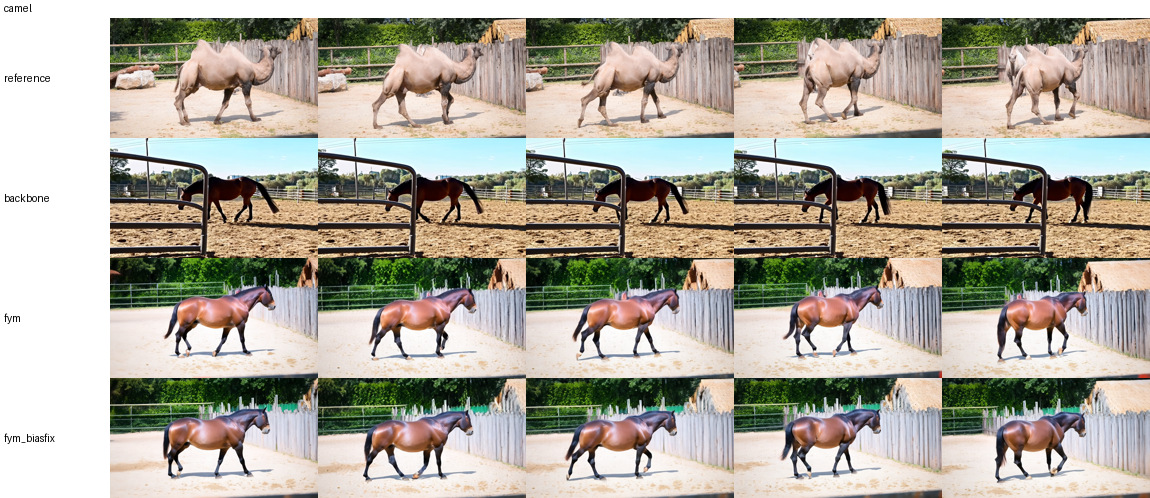

In [7]:
# 7. Pilot: what happened (a failed cell prints its stage, reason and log tail)
import json
from IPython.display import Image as show
for cfg in ["backbone", "fym", "fym_biasfix"]:
    d = pathlib.Path(RUNS, "fym_wan/davis/camel/subject", cfg, "seed1")
    if (d / "done.json").exists():
        j = json.loads((d / "done.json").read_text())
        print(f"{cfg}: done", {k: j.get(k) for k in ("tune_s", "elapsed_s", "peak_gpu_mb")})
    elif (d / "failed.json").exists():
        j = json.loads((d / "failed.json").read_text())
        print(f"{cfg}: FAILED at {j['stage']} ({j['reason_code']}: {j['reason']})")
        for line in j["log_tail"].strip().splitlines()[-15:]:
            print("   ", line)
    else:
        print(f"{cfg}: not run")
    if (d / "tune/tune.json").exists():
        t = json.loads((d / "tune/tune.json").read_text())
        print("   temporal heads per layer:", t["temporal_heads_per_layer"])
        print("   stage seconds:", t["stage_s"])
!cd {REPO} && python fym_bench/contact_sheet.py --runs {RUNS} --clips camel --configs backbone,fym,fym_biasfix --out {DRIVE}/sheets_pilot
sheet = f"{DRIVE}/sheets_pilot/sheet_01.png"
show(sheet) if os.path.exists(sheet) else print("no contact sheet: no finished cells yet")

In [8]:
# 8. Pilot: score it
import pandas as pd
!cd {REPO} && python benchmark/collect.py --runs {RUNS}/fym_wan --manifest {MANIFEST} --annotations {ANNOT} --out {DRIVE}/scores_fym_pilot.csv --cotracker-ref {COTRACKER_REF} --scratch ""
pd.read_csv(f"{DRIVE}/scores_fym_pilot.csv")

284 cells found, 284 to score
Downloading: "https://github.com/facebookresearch/co-tracker/zipball/82e02e8029753ad4ef13cf06be7f4fc5facdda4d" to /root/.cache/torch/hub/82e02e8029753ad4ef13cf06be7f4fc5facdda4d.zip
Downloading: "https://huggingface.co/facebook/cotracker3/resolve/main/scaled_offline.pth" to /root/.cache/torch/hub/checkpoints/scaled_offline.pth
100% 97.2M/97.2M [00:01<00:00, 79.2MB/s]
100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 57.9MiB/s]
Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_deitsmall16_pretrain.pth
100% 82.7M/82.7M [00:00<00:00, 311MB/s]
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated 

,cell,run_tag,split,clip_id,prompt_id,config,seed,prompt,elapsed_s,mf,dir_cos,subjects,n_salient_moving,mf_masked,dir_cos_masked,subject_consistency,clip_i_subject,lpips_bg,iq,temp_cons
0,cogvx2b/davis/bike-packing/subject/ditflow_z/s...,cogvx2b,davis,bike-packing,subject,ditflow_z,1,A bear lifts an electric bicycle onto a roof r...,178.8,0.285584,-0.793312,multi,2,0.355890,0.216080,0.938338,0.942383,0.599248,0.343994,0.983887
1,cogvx5b/davis/bear/subject/backbone/seed1,cogvx5b,davis,bear,subject,backbone,1,A lion walks across boulders in front of a san...,210.7,0.940458,-0.947620,single,1,0.534136,0.716164,0.946798,0.952148,0.584121,0.335693,0.992676
2,cogvx5b/davis/bear/subject/backbone/seed2,cogvx5b,davis,bear,subject,backbone,2,A lion walks across boulders in front of a san...,210.9,0.780932,0.999619,single,1,0.422177,0.591832,0.853556,0.915527,0.598997,0.297119,0.975098
3,cogvx5b/davis/bear/subject/backbone/seed3,cogvx5b,davis,bear,subject,backbone,3,A lion walks across boulders in front of a san...,211.3,0.801967,0.919929,single,1,0.558144,0.439763,0.930222,0.957520,0.652843,0.349854,0.990723
4,cogvx5b/davis/bear/subject/ditflow_rho/seed1,cogvx5b,davis,bear,subject,ditflow_rho,1,A lion walks across boulders in front of a san...,352.9,0.922039,0.982237,single,1,0.443252,-0.030365,0.949871,0.961426,0.534075,0.323730,0.985840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,cogvx5b/davis/kite-walk/subject/smm/seed1,cogvx5b,davis,kite-walk,subject,smm,1,A bear carries a surfboard and red sail along ...,309.9,0.693986,0.999992,multi,3,0.680807,-0.963878,0.966960,0.965820,0.439663,0.401367,0.990234
280,cogvx5b/davis/soapbox/subject/backbone/seed1,cogvx5b,davis,soapbox,subject,backbone,1,A wooden barrel cart and its riders roll over ...,274.8,0.728206,-0.993007,multi,2,0.331277,0.838135,0.983345,0.981445,0.806456,0.329834,0.994141
281,fym_wan/davis/camel/subject/backbone/seed1,fym_wan,davis,camel,subject,backbone,1,A horse walks slowly across a dusty paddock be...,68.6,0.873443,-0.979800,single,1,0.577430,0.250561,0.977719,0.986328,0.607472,0.271484,0.997559
282,fym_wan/davis/camel/subject/fym/seed1,fym_wan,davis,camel,subject,fym,1,A horse walks slowly across a dusty paddock be...,74.4,0.968620,0.999999,single,1,0.857677,0.128896,0.967291,0.980469,0.391848,0.255859,0.990234


## Full run: all 50 clips

Runs in the background with its log on Drive, so a dropped VS Code connection does not stop it. Re-issue cell 9 after a recycled runtime and it resumes where it stopped.

In [ ]:
# 9. Full run, in the background
LOG = f"{DRIVE}/fym_run.log"
!cd {REPO} && nohup python fym_bench/run_davis.py --manifest {MANIFEST} --runs {RUNS} --models {MODELS} --configs backbone,fym >> {LOG} 2>&1 &
print("log:", LOG)

In [ ]:
# 10. Progress (re-run any time)
!tail -n 25 {LOG}
!cat {RUNS}/fym_wan/accounting.json 2>/dev/null

In [ ]:
# 11. Score, C1 floor, paired contrasts (all clips, then single / multi subject), contact sheets
import pandas as pd
SCORES = f"{DRIVE}/scores_fym.csv"
!cd {REPO} && python benchmark/collect.py --runs {RUNS}/fym_wan --manifest {MANIFEST} --annotations {ANNOT} --out {SCORES} --cotracker-ref {COTRACKER_REF} --scratch ""
!cd {REPO} && python benchmark/collect.py --runs {RUNS}/fym_wan --manifest {MANIFEST} --annotations {ANNOT} --out {SCORES} --cotracker-ref {COTRACKER_REF} --scratch "" --control c1
# fym_biasfix exists only for the pilot clip; keep it out of the tables
s = pd.read_csv(SCORES)
s = s[s["config"].isin(["backbone", "fym", "C1"])]
s.to_csv("/content/scores_fym_main.csv", index=False)
!cd {REPO} && python benchmark/analyse.py --scores /content/scores_fym_main.csv --reference backbone --out {DRIVE}/tables_fym.md
for group in ["single", "multi"]:
    s[s["subjects"] == group].to_csv(f"/content/scores_fym_{group}.csv", index=False)
    !cd {REPO} && python benchmark/analyse.py --scores /content/scores_fym_{group}.csv --reference backbone --out {DRIVE}/tables_fym_{group}.md
!cd {REPO} && python fym_bench/contact_sheet.py --runs {RUNS}/fym_wan --configs backbone,fym --out {DRIVE}/sheets